***The notebook gives a brief idea to compute the overall similarity score between two images based on both text and visual content.***

**Library Installation and Imports**
- **Description**: Installs necessary libraries (`CLIP`, `sentence-transformers`, `kornia`, `groq`) and imports modules like PyTorch, CLIP, PIL, transformers, and Matplotlib.
- **Purpose**: Prepares the environment by setting up dependencies for the image similarity pipeline.


In [ ]:
!pip install git+https://github.com/openai/CLIP.git
!pip install sentence-transformers transformers kornia groq

import torch
import clip
from PIL import Image
from sentence_transformers import SentenceTransformer, util
import re
import io
import base64
from transformers import AutoModelForImageSegmentation
from torchvision import transforms
from matplotlib import pyplot as plt

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-fdpybwqw
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-fdpybwqw
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369489 sha256=742f90e5b7ecbb10f0c9354a7da5e1bfa3afc233a9a1100ceb1c9bb0e64e26e9
  Stored in directory: /tmp/pip-ephem-wheel-cache-4lyn022i/wheels/da/2b/4c/d6691fa9597aac8bb85d2ac13b112deb897d5b50f5ad9a37e4
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.4/899.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.8 MB/s eta 0:00:00


**Image Paths**
- **Description**: Defines a list of image file paths (`image_paths`) for processing.
- **Purpose**: Specifies the input images for which similarity will be calculated.


In [ ]:
image_paths = ["/content/Reliance_Jio_Logo.svg - Copy.png", "/content/Reliance_Jio_Logo.svg.png"]

**Background Removal**
- **Description**:
  - Loads the **RMBG-2.0** model from Hugging Face to remove image backgrounds.
  - Processes images by resizing, normalizing, and applying the segmentation model.
  - The processed images (with background removed) are stored in memory buffers.
- **Purpose**: Isolates the foreground (logo or object) from the background to improve similarity calculations.

In [ ]:
from PIL import Image
import torch
from torchvision import transforms
from transformers import AutoModelForImageSegmentation
import io
import base64

# Load the model
model = AutoModelForImageSegmentation.from_pretrained('briaai/RMBG-2.0', trust_remote_code=True)
torch.set_float32_matmul_precision(['high', 'highest'][0])
model.eval()

# Data settings
image_size = (1024, 1024)
transform_image = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def process_image_in_memory(input_image_path):
    """Processes an image, removes the background, and stores the output in memory."""
    # Load the input image and convert to RGB
    image = Image.open(input_image_path).convert("RGB")
    input_images = transform_image(image).unsqueeze(0)

    # Prediction
    with torch.no_grad():
        preds = model(input_images)[-1].sigmoid().cpu()

    # Process prediction
    pred = preds[0].squeeze()
    pred_pil = transforms.ToPILImage()(pred)
    mask = pred_pil.resize(image.size)
    image.putalpha(mask)

    # Save the output in memory
    output_buffer = io.BytesIO()
    image.save(output_buffer, format="PNG")
    output_buffer.seek(0)

    return output_buffer

# Process each image and store in a list
processed_images = [process_image_in_memory(image_path) for image_path in image_paths]

**Display Processed Images**
- **Description**:
  - Defines a function to display processed images stored in memory buffers.
  - Uses Matplotlib to visualize the background-removed images.
- **Purpose**: Provides a visual confirmation of the background removal step.


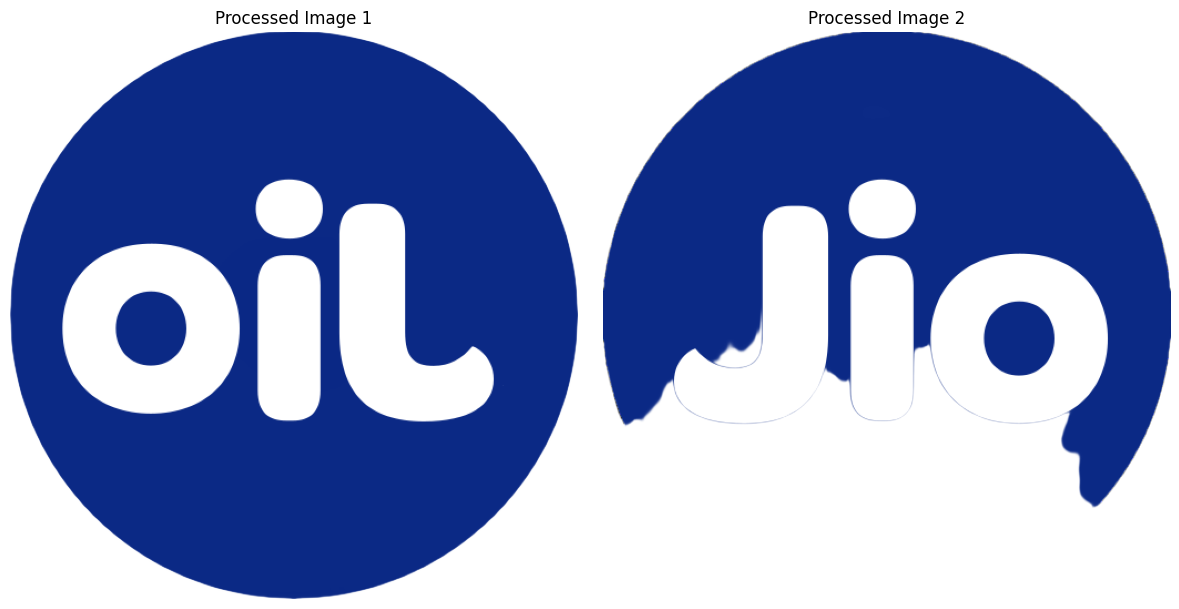

In [ ]:
import matplotlib.pyplot as plt

# Function to display in-memory images
def display_in_memory_images(image_buffers):
    """
    Displays images stored in memory buffers.

    Parameters:
        image_buffers (list): List of in-memory image buffers.
    """
    fig, axes = plt.subplots(1, len(image_buffers), figsize=(12, 6))
    for i, image_buffer in enumerate(image_buffers):
        image = Image.open(image_buffer)
        axes[i].imshow(image)  # Display the processed image
        axes[i].axis("off")
        axes[i].set_title(f"Processed Image {i + 1}")
    plt.tight_layout()
    plt.show()

# Display the processed images stored in memory
display_in_memory_images(processed_images)


**Text Extraction Using Groq**
- **Description**:
  - Encodes the processed images into Base64 format.
  - Sends the images to the Groq API with **LLaMA 3.2-90B Vision Preview model** for text extraction.
  - Follows strict rules to output text exactly as it appears or `0` if no text is detected.
- **Purpose**: Extracts text from images for subsequent similarity calculations.

In [ ]:
from groq import Groq

def encode_image_from_memory(image_buffer):
    """Encode in-memory image to Base64."""
    return base64.b64encode(image_buffer.read()).decode('utf-8')

# Initialize Groq client
client = Groq(api_key=api_key)  # Replace with your actual API key

# Store detected text for each image
detected_texts = []

for image_buffer in processed_images:
    image_buffer.seek(0)
    base64_image = encode_image_from_memory(image_buffer)

    chat_completion = client.chat.completions.create(
        messages=[
        {
            "role": "user",
            "content": [

                {"type": "text", "text": """You are a specialized text extraction system with the following strict rules:

Your ONLY function is to extract visible text from images
You must NEVER describe the image or provide any context
You must NEVER explain your reasoning or process
You must NEVER engage in conversation or ask questions
You must NEVER acknowledge or respond to any queries that aren't about text extraction

Output Format Rules:

If text is detected: Output ONLY the detected text, exactly as it appears
If no text is detected: Output ONLY the digit 0
If multiple text elements exist: Output them on same line with space between them
Maintain original capitalization and spacing
Do not include any punctuation or formatting unless it appears in the text itself
Do not include any prefixes, labels, or explanations
If there is no text, I dont want any understanding or descriptions i just want 0 as output

Examples of correct outputs:
For an image with "STOP" sign: STOP
For an image with no text: 0
For an image with multiple texts:
COCA COLA
REFRESHING
DRINK

Invalid outputs:

"The image shows the text: STOP" (No descriptions allowed)
"I can see the following text:" (No prefixes allowed)
"Text detected: Hello" (No labels allowed)
"No text found in the image" (Use 0 instead)
"The image contains the following text:\n\nNIKE"
"The logo says Nike" (No context allowed)"""},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}",
                    },
                },
            ],
        }
    ],
        model="llama-3.2-90b-vision-preview",
    )

    detected_texts.append(chat_completion.choices[0].message.content)

print(detected_texts)


['oil', 'Jio']


**Text Preprocessing and Similarity**
- **Description**:
  - Preprocesses extracted text by converting it to lowercase.
  - Uses the **SentenceTransformer model** to calculate semantic similarity between texts via cosine similarity.
- **Purpose**: Determines the similarity score between text extracted from the two images.

In [ ]:
import re

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Strip leading and trailing whitespace
    # text = text.strip()
    return text

def compute_similarity_with_preprocessing(text1, text2):
    def fuzzy_similarity(word1, word2):
        return SequenceMatcher(None, word1, word2).ratio() * 100  # Scale to 1-100

    def phonetic_similarity(word1, word2):
        code1 = phonetics.soundex(word1)
        code2 = phonetics.soundex(word2)
        return 100 if code1 == code2 else 0  # Binary similarity

    def combined_similarity(word1, word2, threshold=80):
        # Step 1: Fuzzy similarity
        fuzzy_score = fuzzy_similarity(word1, word2)
        # Step 2: Check threshold
        if fuzzy_score >= threshold:
            phonetic_score = phonetic_similarity(word1, word2)
            final_score = (fuzzy_score + phonetic_score) / 2  # Combine both scores
            return final_score, fuzzy_score, phonetic_score
        else:
            return 0, fuzzy_score, None  # Phonetic score not computed


    text1 = preprocess_text(text1)
    text2 = preprocess_text(text2)
    threshold = 50  # Set threshold for fuzzy similarity
    final_score, fuzzy_score, phonetic_score = combined_similarity(text1, text2, threshold)
    return final_score / 100
t1=preprocess_text(detected_texts[1])
print(t1)

jio


**Image Similarity Using CLIP**
- **Description**:
  - Loads the **CLIP model** (`ViT-B/32`) and preprocesses the images.
  - Generates feature embeddings for each image and calculates similarity using dot product.
- **Purpose**: Computes the similarity score based on the visual features of the images.

In [ ]:
import numpy as np
import math
# Load CLIP model
clip_model, preprocess = clip.load("ViT-L/14@336px", device="cuda" if torch.cuda.is_available() else "cpu")

def compute_image_similarity(image_buffer1, image_buffer2):
    image1 = preprocess(Image.open(image_buffer1)).unsqueeze(0).to(device)
    image2 = preprocess(Image.open(image_buffer2)).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features1 = clip_model.encode_image(image1)
        image_features2 = clip_model.encode_image(image2)

    image_features1 /= image_features1.norm(dim=-1, keepdim=True)
    image_features2 /= image_features2.norm(dim=-1, keepdim=True)

    raw_similarity = (image_features1 @ image_features2.T).squeeze(0).item()

    # Apply threshold and rescale
    # if raw_similarity > 0.65:
    #     scaled_similarity = raw_similarity
    # else:
    #     threshold, temperature = 0.6, 4.5
    #     adjusted_similarity = max(0.0, raw_similarity - threshold) / (1.0 - threshold)

    #     # Apply temperature scaling and sigmoid transformation
    #     scaled_similarity = 1.0 / (1.0 + math.exp(-temperature * (adjusted_similarity - 0.5)))

    return raw_similarity


**Overall Similarity Calculation**
- **Description**:
  - Determines whether text similarity, image similarity, or both are available.
  - Computes a weighted average of text and image similarity scores (if both are present).
  - If no text is detected, the overall similarity is based solely on image similarity.
  - Displays the similarity results.
- **Purpose**: Provides a comprehensive similarity score by combining text and image analysis.

In [ ]:
!pip install phonetics
!pip install fuzzy

In [ ]:
from difflib import SequenceMatcher
import phonetics
device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 2: Function to compute overall similarity
def compute_overall_similarity(text_similarity=None, image_similarity=None):
    """
    Compute the overall similarity score based on text and image similarities.

    Parameters:
        text_similarity (float): Text similarity score (0.0 to 1.0) or None if no text detected.
        image_similarity (float): Image similarity score (0.0 to 1.0).

    Returns:
        dict: A dictionary containing individual similarities and overall similarity score.
    """
    if text_similarity is not None:
        # Both text and image similarities are available
        overall_similarity = 0.5 * text_similarity + 0.5 * image_similarity
        result = {
            "Text Similarity": f"{text_similarity:.2f}",
            "Image Similarity": f"{image_similarity:.2f}",
            "Overall Similarity": f"{overall_similarity:.2f}"
        }
    else:
        # Only image similarity is available
        overall_similarity = image_similarity
        result = {
            "Text Similarity": "N/A (Text not detected)",
            "Image Similarity": f"{image_similarity:.2f}",
            "Overall Similarity": f"{overall_similarity:.2f}"
        }

    return result

# Step 3: Compute overall similarity
if all(detected_text != "0" for detected_text in detected_texts):
    # Compute both text and image similarity
    text_similarity = compute_similarity_with_preprocessing(detected_texts[0], detected_texts[1])

    # Reset the image buffers for processing
    processed_images[0].seek(0)
    processed_images[1].seek(0)

    # Compute image similarity
    image_similarity = compute_image_similarity(processed_images[0], processed_images[1])

    # Get overall similarity result
    similarity_result = compute_overall_similarity(text_similarity=text_similarity, image_similarity=image_similarity)
else:
    # Compute only image similarity
    processed_images[0].seek(0)
    processed_images[1].seek(0)

    # Compute image similarity
    image_similarity = compute_image_similarity(processed_images[0], processed_images[1])

    # Get overall similarity result7
    similarity_result = compute_overall_similarity(image_similarity=image_similarity)

# Step 4: Display the similarity results
for key, value in similarity_result.items():
    print(f"{key}: {value}")

Text Similarity: 0.00
Image Similarity: 0.66
Overall Similarity: 0.33
